# Week 4 Report (pt. 1, potentially)

**Date:** 2026-06-16

## Goals for this week

- [ ] Develop understanding of Spatial Random Effects Models and their implementation in Python
- [ ] Literature Review - aim for completion

## What I did

My primary work focus between our last meeting on 6/12 and today has been on implementing code for various exploratory data analysis processes, as suggested by Dr. Baugh. This includes code to create variograms, research into code for Moran I, Gaussian Process Regressions, code for orthogonal rotation of Principal Components, and refinement of code for Lasso and Ridge regressions. 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pa_gs = pd.read_csv('/home/reu/project/data/pa_data.csv')

## Analysis

*(Add code and markdown cells as needed.)*

In [5]:

# Gaussian Process Regressor code --> currently not functioning correctly
from sklearn.gaussian_process import GaussianProcessRegressor


X = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']
y = ['growing_season_length']

def remove_nulls(data_subset, X, y):
        # Drop rows where any of the specified X columns have nulls
        data_subset_cleaned = data_subset.dropna(subset=X, ignore_index=True)
        # Separate the cleaned dataframe back into X and y
        X_cleaned = data_subset_cleaned[X]
        y_cleaned = data_subset_cleaned[y]
        y_cleaned = y_cleaned.squeeze()
        return X_cleaned, y_cleaned

X_cleaned, y_cleaned = remove_nulls(pa_gs, X, y)

gpr = GaussianProcessRegressor().fit(X_cleaned,y_cleaned)
gpr.score(X_cleaned, y_cleaned)

X_gs = pa_gs[['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico', 'sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']]
prediction = pd.DataFrame(gpr.predict(X_gs))
prediction

ValueError: Input X contains NaN.
GaussianProcessRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

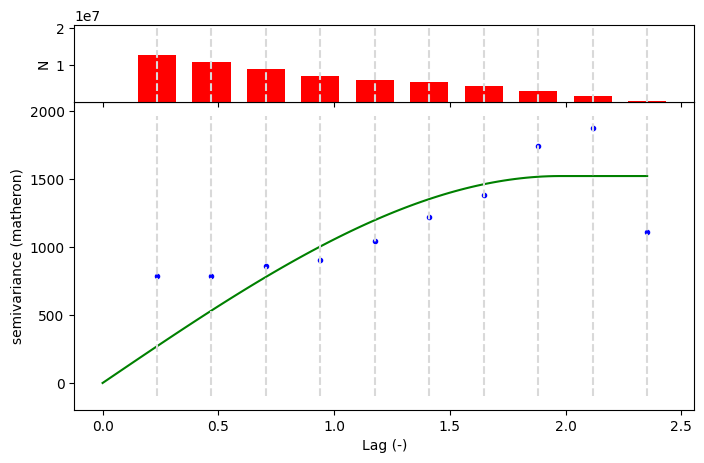

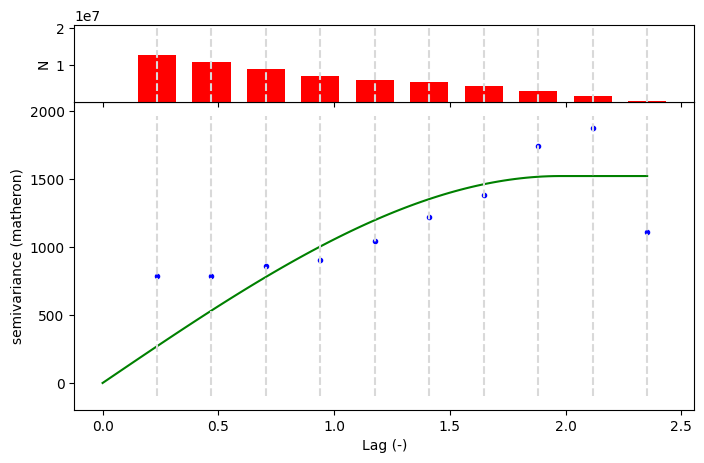

In [6]:
#Variograms Code
import skgstat as skg
pa_gs_no_ohc = ['dtr_annual', 'dtr_spring', 'dtr_summer', 'tmax_annual', 'prcp_annual_mm', 'prcp_growing_season_mm', 
    'prcp_spring_mm', 'latitude', 'longitude', 'elevation_m', 'dist_coast_km', 'dist_greatlakes_km', 'dist_atlantic_km',
    'oni_annual', 'nao_annual', 'nao_djf', 'pna_annual', 'amo_annual', 'sst_north_atlantic',
    'sst_gulf_stream', 'sst_gulf_mexico','sst_tropical_north_atl', 'pwat_eastern_us', 'pwat_southeast_us', 
    'pwat_northeast_us', 'pwat_gulf_coast', 'pwat_station', 'dewpoint_2m_eastern_us', 'soil_moisture_eastern_us',
    'cloud_cover_eastern_us', 'evaporation_eastern_us', 'dewpoint_2m_southeast_us', 'soil_moisture_southeast_us',
    'cloud_cover_southeast_us', 'evaporation_southeast_us', 'dewpoint_2m_northeast_us', 'soil_moisture_northeast_us',
    'cloud_cover_northeast_us', 'evaporation_northeast_us', 'dewpoint_2m_pennsylvania', 'soil_moisture_pennsylvania',
    'cloud_cover_pennsylvania', 'evaporation_pennsylvania', 'dewpoint_station', 'soil_moisture_station',
    'cloud_cover_station', 'evaporation_station']
y_1 = ['growing_season_length']
X_1 = ['latitude', 'longitude']

X_1, y_1 = remove_nulls(pa_gs, X_1, y_1)

coords = np.array(pa_gs['latitude'], pa_gs['longitude'])
values = y_1
V = skg.Variogram(coordinates = coords, values = values)
V.plot()

Code for rotation of principal components can be found in Principal_Component_Analysis.ipynb, Lasso Regression can be found in LassoRegression.ipynb, and Ridge Regression can be found in RidgeRegression.ipynb

## Results and figures

As discussed in the meeting last week, here is a list of what variables affect certain aspects of growing season but not others, with notable analysis where I am able to provide it.

Variables that are influential (coefficient >5) on Last Spring Frost but not First Fall Frost
* PWAT Southeast US
    * Logical Explanation?
    * Relevant Notes?
* 2m Dewpoint Southeast US
    * Logical Explanation?
    * Relevant Notes?

Variables that are influential (coefficient >5) on First Fall Frost but not Last Spring Frost
* Latitude
    * Logical Explanation?
    * Relevant Notes?
        * Interestingly, the Principal Component Regression performed on the PCs for first fall frost indicates that the component including Latitude and Longitude was less influential in the regression on the principal components relative to the first two principal components compared to the PCRs for GSL and LSF. This is seemingly opposite from this observation, which would make me consider whether the other influential variables in that principal component might have an outsized impact in signficantly reducing the influence of that principal component on first fall frost.
        * Jumping off this note, the variables that were important in the loading for the principal component mentioned (PC3 for all PCAs) for first fall frost were as follows:
            * Latitude
            * Longitude
            * Elevation
            * Distance from Great Lakes
            * Distance from Atlantic
            * (slightly lesser but still notable) PWAT Station, Dewpoint Station, Cloud Cover Station
        * therefore primarily a positional based principal component
        * What about station PWAT, Dewpoint, and Cloud Cover makes it so location based variables have less of an impact relative to moisture or SST related variables on first fall frost than on last spring frost or growing season length?
* Longitude
    * Logical Explanation?
    * Relevant Notes?
        * See note on Latitude 

Variables that are influential (coefficient >5) on Growing Season Length but not First Fall or Last Spring Frost
* Distance from Great Lakes
    * Logical Explanation?
        * The logical explanation would be that the specific heat of the water in the lake would push back the dates of both first fall frost and last spring frost, but that doesn't explain how the variable is influential on growing season length but not significantly influential on fff or lsf.
    * Relevant Notes?
* Cloud Cover Northeast US
    * Logical Explanation?
    * Relevant Notes?
        * I find it hard to imagine that something would have an effect on length of the growing season as a whole but not on either the beginning or end of the window calculating that length. What is causing this and the great lakes variable to appear like this?

## Questions and blockers

- This was mentioned in our last meeting but I'm still not entirely sure what inputs a function for Moran I would look like
- Unsure what the problem in my code for Gaussian Process Regression is, but it seems to be relatively useless at this point in time and errors out when I attempt to have it fill in the gaps on a dataset with NaN values.
- Rotation of principal components code seems to be ineffective --> makes the components less tied to certain variables instead of more tied to them, and not sure why.

## Plan for next week

- [ ] Next step 1
- [ ] Next step 2